In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2026-09-08 12:46:40--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 416 Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [3]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [4]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

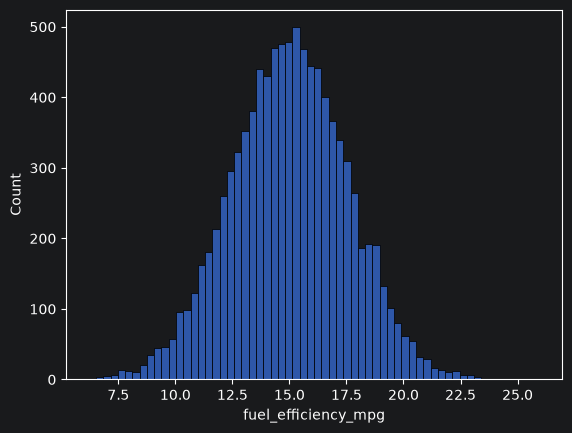

In [5]:
sns.histplot(df['fuel_efficiency_mpg'])

In [6]:
df = df[base]
df.isna().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [7]:
df.horsepower.median()

np.float64(149.0)

In [8]:
np.random.seed(42)
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.shuffle(idx)

In [9]:
df_val = df.iloc[idx[:n_val]]
df_test = df.iloc[idx[n_val:n_val+n_test]]
df_train = df.iloc[idx[n_val+n_test:]]
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

In [10]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [11]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [12]:
def rmse(y,y_pred):
    se = (y-y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [13]:
def prepare_df_0(df):
    df_num = df.copy()
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [14]:
def prepare_df_mean(df):
    df_num = df.copy()
    df_num = df_num.fillna(df.horsepower.mean())
    X = df_num.values
    return X

In [15]:
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

In [16]:
X_train = prepare_df_0(df_train.drop('fuel_efficiency_mpg', axis=1))

w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_df_0(df_val.drop('fuel_efficiency_mpg', axis=1))


pred = w0 + X_val.dot(w)

score = rmse(y_val, pred)

print(round(score, 2))

0.53


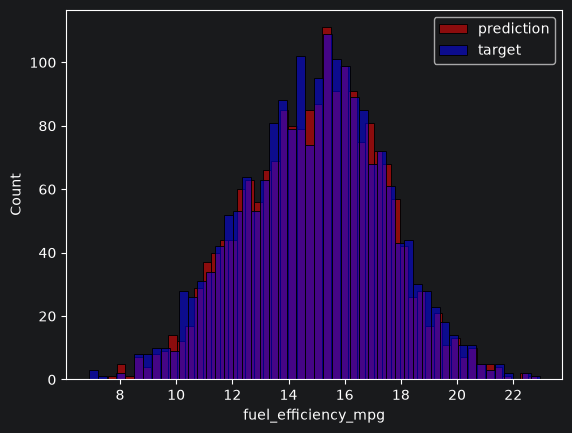

In [17]:
sns.histplot(pred,label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val,label='target', color='blue', alpha=0.5, bins=50)
plt.legend()

In [18]:
X_train = prepare_df_mean(df_train.drop('fuel_efficiency_mpg', axis=1))
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_df_mean(df_val.drop('fuel_efficiency_mpg', axis=1))
pred = w0 + X_val.dot(w)
score = rmse(y_val, pred)
print(round(score, 2))

0.47


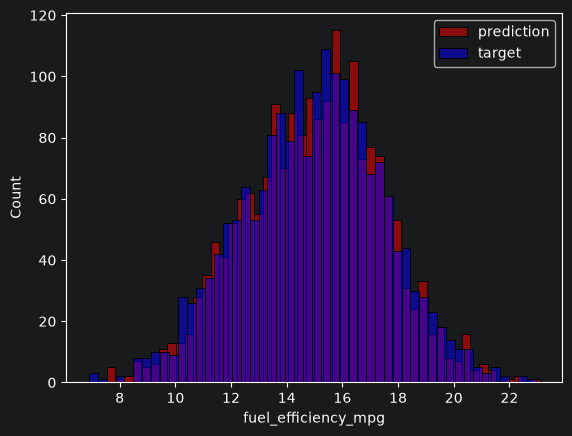

In [19]:
sns.histplot(pred,label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val,label='target', color='blue', alpha=0.5, bins=50)
plt.legend()

In [20]:
def train_linear_regression_reg(X,y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [21]:
for r in [0,0.01, 0.1,1,5,10,100]:
    X_train = prepare_df_0(df_train.drop('fuel_efficiency_mpg', axis=1))
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    X_val = prepare_df_0(df_val.drop('fuel_efficiency_mpg', axis=1))
    pred = w0 + X_val.dot(w)
    score = rmse(y_val, pred)
    print(round(score, 2))

0.53
0.53
0.53
0.54
0.54
0.54
0.54


0

In [22]:
scores = []
for seed in [0,1,2,3,4,5,6,7,8,9]:
    np.random.seed(seed)
    n = len(df)
    n_val = int(n*0.2)
    n_test = int(n*0.2)
    n_train = n - n_val - n_test

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_val = df.iloc[idx[:n_val]]
    df_test = df.iloc[idx[n_val:n_val+n_test]]
    df_train = df.iloc[idx[n_val+n_test:]]
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    df_train = df_train.reset_index(drop=True)
    y_train = df_train.fuel_efficiency_mpg
    y_val = df_val.fuel_efficiency_mpg
    X_train = prepare_df_0(df_train.drop('fuel_efficiency_mpg', axis=1))
    X_val = prepare_df_0(df_val.drop('fuel_efficiency_mpg', axis=1))

    w0, w = train_linear_regression(X_train, y_train)
    pred = w0 + X_val.dot(w)
    score = rmse(y_val, pred)
    scores.append(score)
std = np.std(scores)
print(round(std, 2))

0.01


In [26]:
np.random.seed(9)
n = len(df)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.shuffle(idx)

df_val = df.iloc[idx[:n_val]]
df_test = df.iloc[idx[n_val:n_val+n_test]]
df_train = df.iloc[idx[n_val+n_test:]]
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

y_full_train = df_train.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

X_full_train = prepare_df_0(df_train.drop('fuel_efficiency_mpg', axis=1))
X_test = prepare_df_0(df_test.drop('fuel_efficiency_mpg', axis=1))

w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)
pred = w0 + X_val.dot(w)
score = rmse(y_val, pred)
print(round(score, 2))

0.52
